In [ ]:
# 파일 및 디렉토리 경로를 객체 지향적으로 다룰 수 있는 모듈 (. 으로 경로 설정 가능하게..)
from pathlib import Path

In [ ]:
root = Path('./pascal_datasets')  # 객체 생성
Path('./pascal_datasets/trainval').mkdir(parents=True, exist_ok=True)  # 부모(pascal_datasets)가 없으면 만들고, 폴더가 있으면 그대로 둬라
Path('./pascal_datasets/test').mkdir(parents=True, exist_ok=True)

In [ ]:
for path1 in ('images', 'labels'):
    for path2 in ('train2007', 'val2007', 'test2007'):
        # ./pascal_datasets/VOC/images/train2007
        new_path = root / 'VOC' / path1 / path2
        new_path.mkdir(parents=True, exist_ok=True)

```
# 프로젝트 구조 만들기
pascal_datasets
pascal_datasets/trainval
pascal_datasets/test
pascal_datasets/VOC
pascal_datasets/VOC/images
pascal_datasets/VOC/labels
pascal_datasets/VOC/images/train2007
pascal_datasets/VOC/images/val2007
pascal_datasets/VOC/images/test2007
pascal_datasets/VOC/labels/train2007
pascal_datasets/VOC/labels/val2007
pascal_datasets/VOC/labels/test2007
```

In [ ]:
%cd /content/pascal_datasets/trainval

/content/pascal_datasets/trainval


In [ ]:
!unzip -q VOCtrainval_06-Nov-2007.zip

In [ ]:
%cd /content/pascal_datasets/test

/content/pascal_datasets/test


In [ ]:
!unzip -q VOCtest_06-Nov-2007.zip

In [ ]:
%cd /content/pascal_datasets

/content/pascal_datasets


In [ ]:
# 어노테이션을 YOLO 형식으로 변환
!git clone https://github.com/ssaru/convert2Yolo.git

Cloning into 'convert2Yolo'...
remote: Enumerating objects: 215, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 215 (delta 38), reused 35 (delta 35), pack-reused 172 (from 1)
Receiving objects: 100% (215/215), 994.67 KiB | 26.17 MiB/s, done.
Resolving deltas: 100% (95/95), done.


In [ ]:
%cd /content/pascal_datasets/convert2Yolo

/content/pascal_datasets/convert2Yolo


In [ ]:
# requirements.txt: Python 프로젝트에서 필요한 모든 패키지(라이브러리)와 그 버전 정보를 기록한 텍스트 파일.
# AI/딥러닝, 웹 개발자들이 공통 환경에서 동일한 라이브러리를 설치하기 위해 사용하는 파일.
%pip install -qr requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.1/39.1 MB 15.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 12.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 77.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.3/212.3 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.9/510.9 kB 38.4 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for matplotlib
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel di

In [ ]:
# datasets: 데이터셋이 VOC 형식임을 지정
# img_path: 이미지 파일 경로
# label: 어노테이션(xml) 경로
# convert_output_path: YOLO 형식으로 변환된 라벨 저장 경로
# img_type: 사용할 이미지 파일 확장자
# manifest_path: 변환 과정에서 사용할 추가적인 정보 파일 저장 경로
# cls_list_file: VOC에서 사용할 클래스 목록이 정의된 파일


!python example.py \
    --datasets VOC \
    --img_path /content/pascal_datasets/trainval/VOCdevkit/VOC2007/JPEGImages \
    --label /content/pascal_datasets/trainval/VOCdevkit/VOC2007/Annotations \
    --convert_output_path /content/pascal_datasets/VOC/labels/train2007 \
    --img_type '.jpg' \
    --manifest_path /content \
    --cls_list_file ./voc.names



VOC Parsing:   |████████████████████████████████████████| 100.0% (5011/5011)  Complete


YOLO Generating:|████████████████████████████████████████| 100.0% (5011/5011)  Complete


YOLO Saving:   |████████████████████████████████████████| 100.0% (5011/5011)  Complete



In [ ]:
!python example.py \
    --datasets VOC \
    --img_path /content/pascal_datasets/test/VOCdevkit/VOC2007/JPEGImages \
    --label /content/pascal_datasets/test/VOCdevkit/VOC2007/Annotations \
    --convert_output_path /content/pascal_datasets/VOC/labels/test2007 \
    --img_type '.jpg' \
    --manifest_path /content \
    --cls_list_file ./voc.names


VOC Parsing:   |████████████████████████████████████████| 100.0% (4952/4952)  Complete


YOLO Generating:|████████████████████████████████████████| 100.0% (4952/4952)  Complete


YOLO Saving:   |████████████████████████████████████████| 100.0% (4952/4952)  Complete



In [ ]:
# /content/pascal_datasets/trainval/VOCdevkit/VOC2007/ImageSets/Main/val.txt 파일을 읽어서
# /content/pascal_datasets/VOC/labels/train2007 파일 중 txt 문서에 있는 파일을
# /content/pascal_datasets/VOC/labels/val2007 으로 옮기기

import shutil

path = '/content/pascal_datasets/trainval/VOCdevkit/VOC2007/ImageSets/Main/val.txt'

with open(path) as f:
    image_ids = f.read().strip().split()
    for id in image_ids:
        ori_path = '/content/pascal_datasets/VOC/labels/train2007'
        mv_path = '/content/pascal_datasets/VOC/labels/val2007'
        shutil.move(f'{ori_path}/{id}.txt', f'{mv_path}/{id}.txt')

In [ ]:
# /content/pascal_datasets/trainval/VOCdevkit/VOC2007/JPEGImages 와
# /content/pascal_datasets/test/VOCdevkit/VOC2007/JPEGImages 에서
# 이미지를 가져와 디렉토리에 맞게 저장

import os

path = '/content/pascal_datasets'

for folder, subset in ('trainval', 'train2007'), ('trainval', 'val2007'), ('test', 'test2007'):
    ex_imgs_path = f'{path}/{folder}/VOCdevkit/VOC2007/JPEGImages'
    label_path = f'{path}/VOC/labels/{subset}'
    img_path = f'{path}/VOC/images/{subset}'
    print(subset, ": ", len(os.listdir(label_path)))
    for lbs_list in os.listdir(label_path):
        shutil.move(os.path.join(ex_imgs_path, lbs_list.split('.')[0]+'.jpg'),
                    os.path.join(img_path, lbs_list.split('.')[0]+'.jpg'))

train2007 :  2501
val2007 :  2510
test2007 :  4952


In [ ]:
%cd /content

/content


[1단계] YOLO 설치

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 105.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 88.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [ ]:
# ultralytics 라이브러리에서 YOLO 클래스(객체)를 가져옵니다.
# 이 클래스를 이용해서 모델을 불러오고, 학습하고, 추론 할 수 있다.
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


[2단계] 데이터 준비 (data.yaml + 이미지 + 라벨)

[3단계] 모델 학습

In [ ]:
# data: 데이터셋 설정 파일
# epochs: 학습 에포크 수
# batch: 배치 크기
# imgsz: 입력 이미지 크기
# device: GPU(0), CPU(-1)
# workers: 데이터 로딩에 사용할 CPU 스레드 수
# name: 학습 결과 저장 폴더명

model = YOLO('yolov8s.pt')  # 사전 학습된 YOLOv8n 모델 불러오기

In [ ]:
results = model.train(
    data='custom_voc.yaml',  # 데이터셋 경로
    epochs=10,
    batch=32,
    imgsz=640,
    device=0,  # 0: GPU, -1: CPU
    workers=2,  # 데이터 로딩에 사용하는 subprocess 수
    name='custom_s'   # 결과 저장 디렉토리 이름 (runs/detect/custom_s/)
)

Ultralytics 8.3.174 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=custom_voc.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=custom_s, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True, profil

Overriding model.yaml nc=80 with nc=20

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytic

Model summary: 129 layers, 11,143,340 parameters, 11,143,324 gradients, 28.7 GFLOPs

Transferred 349/355 items from pretrained weights
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...


AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 46.5±24.0 MB/s, size: 85.1 KB)


train: Scanning /content/pascal_datasets/VOC/labels/train2007... 2501 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2501/2501 [00:05<00:00, 446.62it/s]

...

      10/10      6.85G     0.8287     0.6899      1.098          6        640: 100%|██████████| 79/79 [00:44<00:00,  1.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 40/40 [00:21<00:00,  1.85it/s]

                   all       2510       7818      0.801      0.698      0.779      0.559



10 epochs completed in 0.196 hours.
Optimizer stripped from runs/detect/custom_s/weights/last.pt, 22.5MB
Optimizer stripped from runs/detect/custom_s/weights/best.pt, 22.5MB

Validating runs/detect/custom_s/weights/best.pt...
Ultralytics 8.3.174 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,133,324 parameters, 0 gradients, 28.5 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 40/40 [00:24<00:00,  1.65it/s]


                   all       2510       7818      0.812      0.689      0.779      0.559
             aeroplane        127        175      0.822      0.777      0.839      0.613
               bicycle        133        216      0.861      0.746      0.828      0.595
                  bird        151        305      0.848      0.621      0.734      0.472
                  boat        101        190      0.698      0.571      0.661      0.415
                bottle        109        296      0.808      0.564      0.701      0.483
                   bus         97        141      0.903      0.594      0.764      0.643
                   car        359        818      0.861      0.742      0.847      0.631
                   cat        178        198      0.814      0.793      0.832      0.649
                 chair        290        706      0.691      0.574      0.646      0.429
                   cow         75        171      0.832      0.649      0.795      0.608
           diningtabl

[4단계] 추론

In [ ]:
# 학습된 모델 로드
model = YOLO("runs/detect/custom_s/weights/best.pt")

# 검증 수행
results = model.val(
    data="custom_voc.yaml",  # 데이터셋 설정
    imgsz=640,               # 이미지 크기
    iou=0.5,                 # IoU 임계값
    batch=32,                # 배치 크기
    device=0,                # GPU 사용
    workers=2,               # 데이터 로드 시 병렬 처리할 워커 수
    half=True,               # FP16 연산으로 속도 향상 (GPU에서만 지원)
    split="test"             # 검증 데이터셋으로 'test' split 사용
)

print(results)

Ultralytics 8.3.174 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,133,324 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 62.7±15.4 MB/s, size: 106.9 KB)


val: Scanning /content/pascal_datasets/VOC/labels/test2007... 4952 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4952/4952 [00:08<00:00, 568.26it/s]

val: New cache created: /content/pascal_datasets/VOC/labels/test2007.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 155/155 [00:43<00:00,  3.60it/s]


                   all       4952      14976      0.782      0.705      0.775      0.548
             aeroplane        205        311      0.871      0.772      0.839      0.596
               bicycle        250        389       0.84      0.776      0.841      0.602
                  bird        289        576      0.828      0.675       0.76        0.5
                  boat        176        393      0.692      0.527      0.615      0.343
                bottle        240        657      0.806      0.569      0.665      0.433
                   bus        183        254      0.842      0.642      0.786      0.651
                   car        775       1541      0.851      0.791      0.875      0.653
                   cat        332        370      0.784      0.814      0.829      0.612
                 chair        545       1374      0.653      0.577      0.638      0.413
                   cow        127        329      0.813      0.769      0.851      0.598
           diningtabl

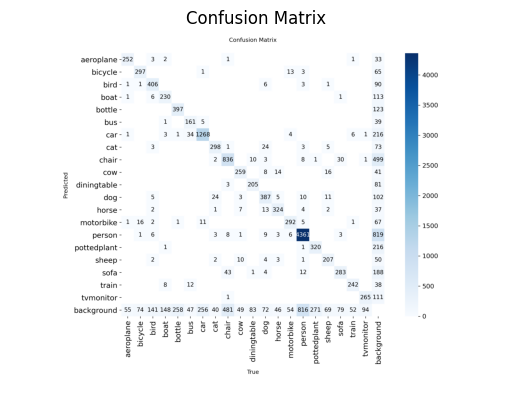

In [ ]:
# YOLO 모델 검증 결과 중 하나인 Confusion Matrix(혼동 행렬) 이미지를 불러와서 화면에 시각화
# YOLO 학습/검증 후에 성능을 눈으로 확인하고 싶을 때 자주 사용됨
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('runs/detect/val/confusion_matrix.png')
plt.imshow(img)
plt.axis('off')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#  YOLO 모델로 테스트 이미지 폴더에 대해 객체 탐지(Prediction)를 수행하고, 탐지 결과를 이미지 파일 + 텍스트 파일로 저장

# 학습된 YOLO 모델을 로드
# best.pt는 학습 중 성능이 가장 좋았던 모델
model = YOLO("runs/detect/custom_s/weights/best.pt")

# 객체 탐지 수행
results = model.predict(
    source="/content/pascal_datasets/VOC/images/custom2007",  # 테스트 이미지 폴더
    imgsz=640,           # 입력 이미지 크기
    conf=0.25,           # 신뢰도(Confidence) 임계값
    device=0,            # GPU 사용 (CPU 사용 시 "cpu")
    save=True,           # 탐지 결과 저장
    save_txt=True,       # 탐지 결과를 txt 형식으로 저장 (YOLO 포맷)
    save_conf=True       # 탐지된 객체의 신뢰도 점수도 저장
)

print(results)


image 1/5 /content/pascal_datasets/VOC/images/custom2007/000254.jpg: 448x640 4 cars, 44.7ms
image 2/5 /content/pascal_datasets/VOC/images/custom2007/000442.jpg: 480x640 1 cat, 43.9ms
image 3/5 /content/pascal_datasets/VOC/images/custom2007/000539.jpg: 480x640 1 dog, 1 horse, 1 person, 13.1ms
image 4/5 /content/pascal_datasets/VOC/images/custom2007/001300.jpg: 640x416 1 horse, 40.0ms
image 5/5 /content/pascal_datasets/VOC/images/custom2007/001967.jpg: 448x640 1 bird, 13.7ms
Speed: 2.1ms preprocess, 31.1ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)
Results saved to runs/detect/predict
5 labels saved to runs/detect/predict/labels
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'aeroplane', 1: 'bicycle', 2: 'bird', 3: 'boat', 4: 'bottle', 5: 'bus', 6: 'car', 7: 'cat', 8: 'chair', 9: 'cow', 10: 'diningtable', 11: 'dog', 12: 'horse', 13: 'motorbike', 14: 'person', 15: 'po

[5단계] 결과 확인 (시각화)

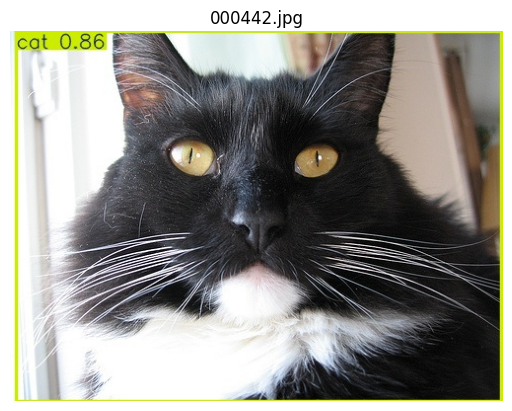

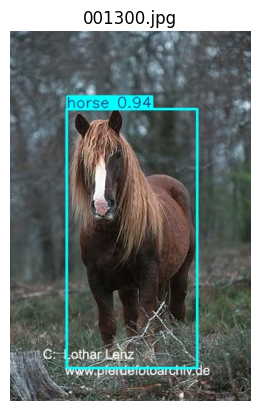

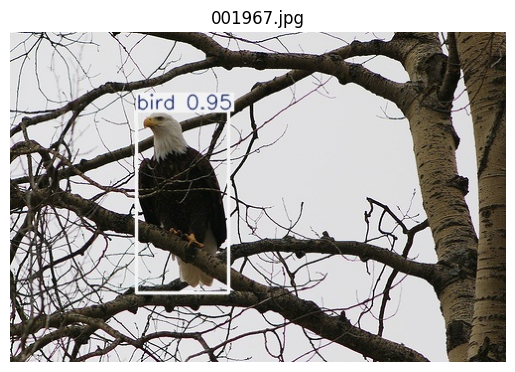

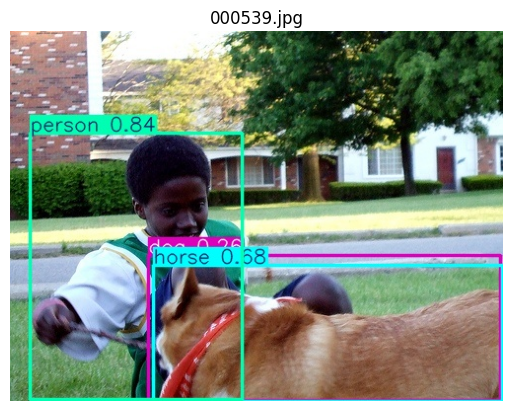

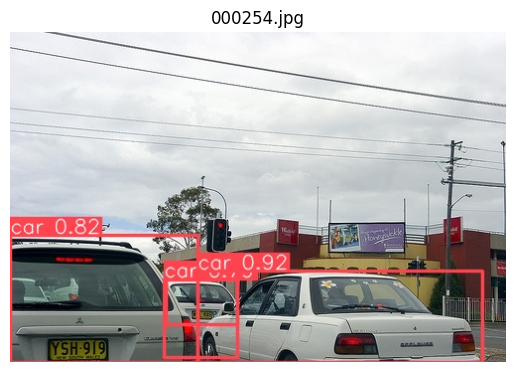

In [ ]:
# 결과 확인 (이미지 시각화)
import matplotlib.pyplot as plt
from PIL import Image
import glob

image_paths = glob.glob("runs/detect/predict/*.jpg")

for path in image_paths:
    img = Image.open(path)
    plt.imshow(img)
    plt.title(path.split('/')[-1])
    plt.axis('off')
    plt.show()
